In [12]:
# prerequisites
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.autograd import Variable
from torchvision.utils import save_image
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
bs = 100

transform = transforms.Compose([
    transforms.ToTensor(),  # Convert image to tensor (shape: [1, 28, 28])
    transforms.Normalize((0.286,), (0.353,))  # Mean and std for Fashion MNIST (1 channel)
])

train_dataset = datasets.FashionMNIST(
    root='./data', 
    train=True, 
    download=True, 
    transform=transform
)

# Create the DataLoader
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=64,  # Adjust batch size as needed
    shuffle=True
)

  5%|▍         | 1.25M/26.4M [01:10<1:08:37, 6.12kB/s]

In [3]:
class Generator(nn.Module):
    def __init__(self, g_input_dim, g_output_dim):
        super(Generator, self).__init__()       
        self.fc1 = nn.Linear(g_input_dim, 256)
        self.fc2 = nn.Linear(self.fc1.out_features, self.fc1.out_features*2)
        self.fc3 = nn.Linear(self.fc2.out_features, self.fc2.out_features*2)
        self.fc4 = nn.Linear(self.fc3.out_features, g_output_dim)
    
    # forward method
    def forward(self, x): 
        x = F.leaky_relu(self.fc1(x), 0.2)
        x = F.leaky_relu(self.fc2(x), 0.2)
        x = F.leaky_relu(self.fc3(x), 0.2)
        return torch.tanh(self.fc4(x))
    
class Discriminator(nn.Module):
    def __init__(self, d_input_dim):
        super(Discriminator, self).__init__()
        self.fc1 = nn.Linear(d_input_dim, 1024)
        self.fc2 = nn.Linear(self.fc1.out_features, self.fc1.out_features//2)
        self.fc3 = nn.Linear(self.fc2.out_features, self.fc2.out_features//2)
        self.fc4 = nn.Linear(self.fc3.out_features, 1)
    
    # forward method
    def forward(self, x):
        x = F.leaky_relu(self.fc1(x), 0.2)
        x = F.dropout(x, 0.3)
        x = F.leaky_relu(self.fc2(x), 0.2)
        x = F.dropout(x, 0.3)
        x = F.leaky_relu(self.fc3(x), 0.2)
        x = F.dropout(x, 0.3)
        return torch.sigmoid(self.fc4(x))

In [4]:
# build network
z_dim = 100
mnist_dim = train_dataset.train_data.size(1) * train_dataset.train_data.size(2)

G = Generator(g_input_dim = z_dim, g_output_dim = mnist_dim).to(device)
D = Discriminator(mnist_dim).to(device)

/home/vu-lab03-pc24/Downloads/deep-fake/.venv/lib/python3.12/site-packages/torchvision/datasets/mnist.py:76: UserWarning: train_data has been renamed data
  warnings.warn("train_data has been renamed data")


In [5]:
G

Generator(
  (fc1): Linear(in_features=100, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=512, bias=True)
  (fc3): Linear(in_features=512, out_features=1024, bias=True)
  (fc4): Linear(in_features=1024, out_features=784, bias=True)
)

In [6]:
D

Discriminator(
  (fc1): Linear(in_features=784, out_features=1024, bias=True)
  (fc2): Linear(in_features=1024, out_features=512, bias=True)
  (fc3): Linear(in_features=512, out_features=256, bias=True)
  (fc4): Linear(in_features=256, out_features=1, bias=True)
)

In [7]:
# loss
criterion = nn.BCELoss() 

# optimizer
lr = 0.0002 
G_optimizer = optim.Adam(G.parameters(), lr = lr)
D_optimizer = optim.Adam(D.parameters(), lr = lr)

In [8]:
def D_train(x):
    #=======================Train the discriminator=======================#
    D.zero_grad()

    # train discriminator on real
    x_real, y_real = x.view(-1, mnist_dim), torch.ones(bs, 1)
    x_real, y_real = Variable(x_real.to(device)), Variable(y_real.to(device))

    D_output = D(x_real)
    D_real_loss = criterion(D_output, y_real)
    D_real_score = D_output

    # train discriminator on facke
    z = Variable(torch.randn(bs, z_dim).to(device))
    x_fake, y_fake = G(z), Variable(torch.zeros(bs, 1).to(device))

    D_output = D(x_fake)
    D_fake_loss = criterion(D_output, y_fake)
    D_fake_score = D_output

    # gradient backprop & optimize ONLY D's parameters
    D_loss = D_real_loss + D_fake_loss
    D_loss.backward()
    D_optimizer.step()
        
    return  D_loss.data.item()

In [9]:
def G_train(x):
    #=======================Train the generator=======================#
    G.zero_grad()

    z = Variable(torch.randn(bs, z_dim).to(device))
    y = Variable(torch.ones(bs, 1).to(device))

    G_output = G(z)
    D_output = D(G_output)
    G_loss = criterion(D_output, y)

    # gradient backprop & optimize ONLY G's parameters
    G_loss.backward()
    G_optimizer.step()
        
    return G_loss.data.item()

In [ ]:
n_epoch = 200
for epoch in range(1, n_epoch+1):           
    D_losses, G_losses = [], []
    for batch_idx, (x, _) in enumerate(train_loader):
        D_losses.append(D_train(x))
        G_losses.append(G_train(x))

    print('[%d/%d]: loss_d: %.3f, loss_g: %.3f' % (
            (epoch), n_epoch, torch.mean(torch.FloatTensor(D_losses)), torch.mean(torch.FloatTensor(G_losses))))

[1/100]: loss_d: 0.914, loss_g: 3.021
[2/100]: loss_d: 0.244, loss_g: 6.320
[3/100]: loss_d: 0.242, loss_g: 5.758
[4/100]: loss_d: 0.215, loss_g: 5.631
[5/100]: loss_d: 0.188, loss_g: 5.818
[6/100]: loss_d: 0.195, loss_g: 5.317
[7/100]: loss_d: 0.183, loss_g: 5.551
[8/100]: loss_d: 0.173, loss_g: 5.371
[9/100]: loss_d: 0.180, loss_g: 5.318
[10/100]: loss_d: 0.172, loss_g: 5.156
[11/100]: loss_d: 0.164, loss_g: 5.304
[12/100]: loss_d: 0.175, loss_g: 5.121
[13/100]: loss_d: 0.175, loss_g: 5.027
[14/100]: loss_d: 0.176, loss_g: 5.049
[15/100]: loss_d: 0.169, loss_g: 5.102
[16/100]: loss_d: 0.168, loss_g: 5.131
[17/100]: loss_d: 0.170, loss_g: 5.010
[18/100]: loss_d: 0.171, loss_g: 4.860
[19/100]: loss_d: 0.165, loss_g: 4.873
[20/100]: loss_d: 0.167, loss_g: 4.789
[21/100]: loss_d: 0.160, loss_g: 4.783
[22/100]: loss_d: 0.158, loss_g: 4.773
[23/100]: loss_d: 0.152, loss_g: 4.784
[24/100]: loss_d: 0.141, loss_g: 4.919
[25/100]: loss_d: 0.151, loss_g: 4.792
[26/100]: loss_d: 0.140, loss_g: 4

In [25]:
%pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.2.1-py3-none-any.whl.metadata (5.0 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 245.4 kB/s eta 0:00:0000:0100:02
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 243.6 kB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 163.5 kB/s eta 0:00:00a 0:00:01
Using cached pyparsing-3.2.1-py3-none-any.whl (107 kB)
Note: you may need to restart the kernel to use updated packages.


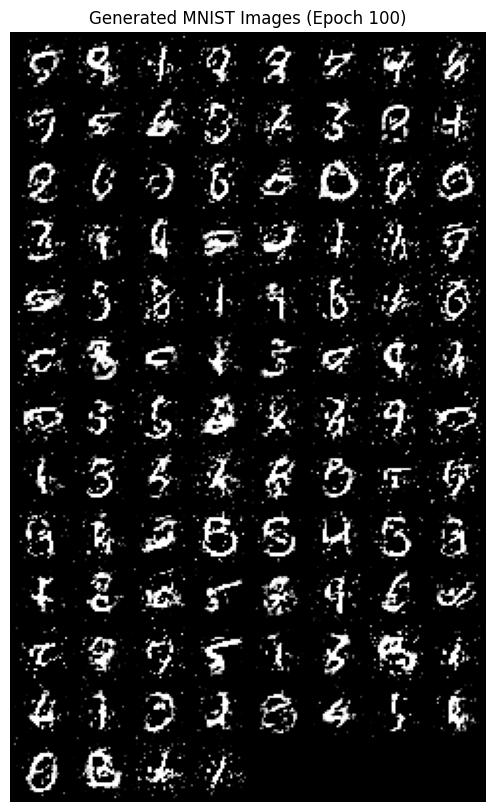

Image saved to ./samples/sample_epoch_100.png


In [11]:
import os
from PIL import Image
import numpy as np

import matplotlib.pyplot as plt

# Create samples directory if it doesn't exist
os.makedirs('./samples', exist_ok=True)

with torch.no_grad():
    test_z = Variable(torch.randn(bs, z_dim).to(device))
    generated = G(test_z)
    
    # Save image
    save_path = './samples/sample_epoch_{}.png'.format(n_epoch)
    save_image(generated.view(generated.size(0), 1, 28, 28), save_path)
    
    # Display the image
    img = Image.open(save_path)
    plt.figure(figsize=(10, 10))
    plt.imshow(np.array(img), cmap='gray')
    plt.title(f"Generated MNIST Images (Epoch {n_epoch})")
    plt.axis('off')
    plt.show()
    
    print(f"Image saved to {save_path}")